In [1]:
import os
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from pathlib import Path

from ddw.utils.mrctools import load_mrc_data

C:\Users\chris\anaconda3\envs\ddw_env\lib\site-packages\lightning_utilities\core\imports.py:10: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
print(os.getcwd())

C:\Users\chris\Desktop\Fabio\semester-project-deepdewedge\notebooks


In [3]:
#load the curves for the plots
subexp01_curves = pd.read_csv("../results/subexp01/subexp01_fsc_curves.csv")
subexp02_curves = pd.read_csv("../results/subexp02/subexp02_fsc_curves.csv")

#load the summaries
subexp01_summary = pd.read_csv("../results/subexp01/even_odd_fsc_angle_sweep_summary.csv")
subexp02_summary = pd.read_csv("../results/subexp02/even_odd_diff_models_fsc_summary.csv")

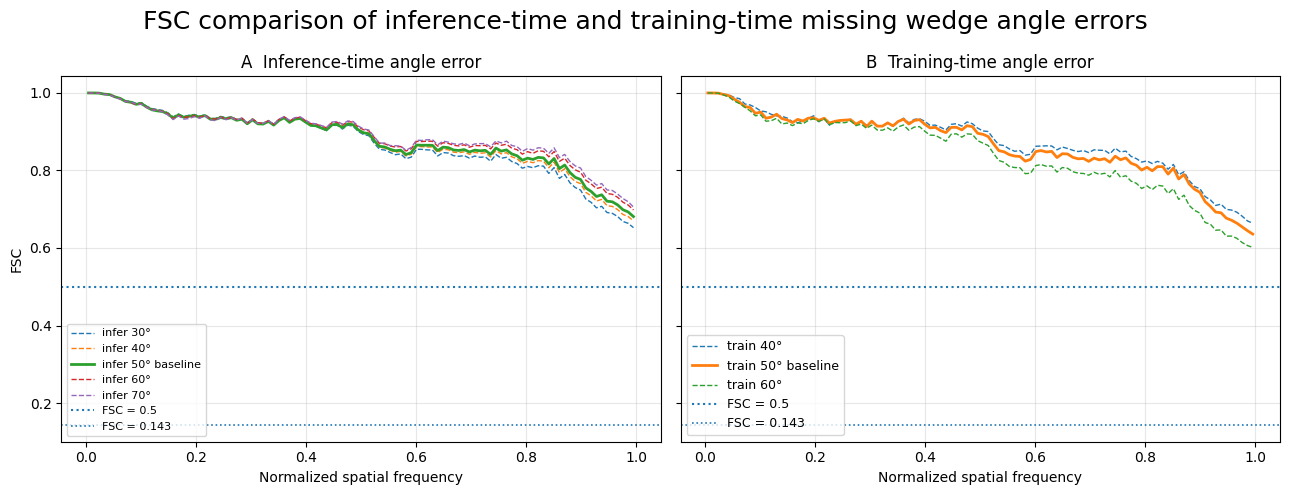

Saved:
C:\Users\chris\Desktop\Fabio\semester-project-deepdewedge\figures\comparison\subexp01_vs_subexp02_fsc_comparison.png
C:\Users\chris\Desktop\Fabio\semester-project-deepdewedge\figures\comparison\subexp01_vs_subexp02_fsc_comparison.pdf


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

# -------------------------
# Panel A: Sub-Exp 1
# -------------------------
ax = axes[0]

for infer_angle in sorted(subexp01_curves["inferred_mw_angle"].unique()):
    data = subexp01_curves[subexp01_curves["inferred_mw_angle"] == infer_angle]
    
    if infer_angle == 50:
        ax.plot(
            data["frequency_normalized"],
            data["fsc"],
            linewidth=2.0,
            label=f"infer {infer_angle}° baseline"
        )
    else:
        ax.plot(
            data["frequency_normalized"],
            data["fsc"],
            linestyle="--",
            linewidth=1.0,
            label=f"infer {infer_angle}°"
        )

ax.axhline(0.5, linestyle=":", linewidth=1.5, label="FSC = 0.5")
ax.axhline(0.143, linestyle=":", linewidth=1.2, label="FSC = 0.143")

ax.set_title("A  Inference-time angle error")
ax.set_xlabel("Normalized spatial frequency")
ax.set_ylabel("FSC")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8, loc="lower left")


# -------------------------
# Panel B: Sub-Exp 2
# -------------------------
ax = axes[1]

for train_angle in sorted(subexp02_curves["trained_mw_angle"].unique()):
    data = subexp02_curves[subexp02_curves["trained_mw_angle"] == train_angle]
    
    if train_angle == 50:
        ax.plot(
            data["frequency_normalized"],
            data["fsc"],
            linewidth=2.0,
            label=f"train {train_angle}° baseline"
        )
    else:
        ax.plot(
            data["frequency_normalized"],
            data["fsc"],
            linestyle="--",
            linewidth=1.0,
            label=f"train {train_angle}°"
        )

ax.axhline(0.5, linestyle=":", linewidth=1.5, label="FSC = 0.5")
ax.axhline(0.143, linestyle=":", linewidth=1.2, label="FSC = 0.143")

ax.set_title("B  Training-time angle error")
ax.set_xlabel("Normalized spatial frequency")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9, loc="lower left")

fig.suptitle("FSC comparison of inference-time and training-time missing wedge angle errors", fontsize=18)
fig.tight_layout()

os.makedirs("../figures/comparison", exist_ok=True)

png_path = "../figures/comparison/subexp01_vs_subexp02_fsc_comparison.png"
pdf_path = "../figures/comparison/subexp01_vs_subexp02_fsc_comparison.pdf"

fig.savefig(png_path, dpi=300, bbox_inches="tight")
fig.savefig(pdf_path, bbox_inches="tight")

plt.show()

print("Saved:")
print(os.path.abspath(png_path))
print(os.path.abspath(pdf_path))

### Report Plot

C:\Users\chris\AppData\Local\Temp\ipykernel_15244\232505109.py:98: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


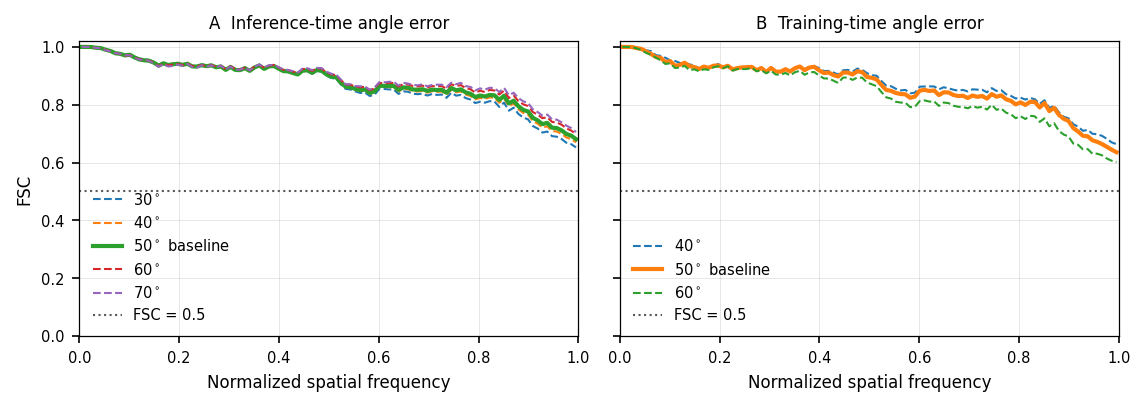

In [7]:
plt.rcParams.update({
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "legend.fontsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

cm = 1 / 2.54
fig, axes = plt.subplots(
    1, 2,
    figsize=(19.5 * cm, 7 * cm),
    sharey=True,
    constrained_layout=True
)

# ------------------
# Left: inference-time angle sweep
# ------------------
ax = axes[0]

for infer_angle in sorted(subexp01_curves["inferred_mw_angle"].unique()):
    data = subexp01_curves[subexp01_curves["inferred_mw_angle"] == infer_angle]
    
    if infer_angle == 50:
        ax.plot(
            data["frequency_normalized"],
            data["fsc"],
            linewidth=2.0,
            label=fr"${infer_angle}^\circ$ baseline"
        )
    else:
        ax.plot(
            data["frequency_normalized"],
            data["fsc"],
            linestyle="--",
            linewidth=1.0,
            label=fr"${infer_angle}^\circ$"
        )
        

ax.axhline(0.5, linestyle=":", linewidth=1.0, color="0.35", label="FSC = 0.5")
#ax.axhline(0.143, linestyle=":", linewidth=1.0, color="0.55", label="FSC = 0.143")

ax.set_title("A  Inference-time angle error")
ax.set_xlabel("Normalized spatial frequency")
ax.set_ylabel("FSC")
ax.set_xlim(0, 1.0)
ax.set_ylim(0, 1.02)
ax.grid(True, linewidth=0.4, alpha=0.35)
ax.legend(frameon=False, loc="lower left")

# ------------------
# Right: training-time angle mismatch
# ------------------
ax = axes[1]


for train_angle in sorted(subexp02_curves["trained_mw_angle"].unique()):
    data = subexp02_curves[subexp02_curves["trained_mw_angle"] == train_angle]
    
    if train_angle == 50:
        ax.plot(
            data["frequency_normalized"],
            data["fsc"],
            linewidth=2.0,
            label=fr"${train_angle}^\circ$ baseline"
        )
    else:
        ax.plot(
            data["frequency_normalized"],
            data["fsc"],
            linestyle="--",
            linewidth=1.0,
            label=fr"${train_angle}^\circ$"
        )


ax.axhline(0.5, linestyle=":", linewidth=1.0, color="0.35", label="FSC = 0.5")
#ax.axhline(0.143, linestyle=":", linewidth=1.0, color="0.55", label="FSC = 0.143")

ax.set_title("B  Training-time angle error")
ax.set_xlabel("Normalized spatial frequency")
ax.set_xlim(0, 1.0)
ax.set_ylim(0, 1.02)
ax.grid(True, linewidth=0.4, alpha=0.35)
ax.legend(frameon=False, loc="lower left")

for ax in axes:
    for spine in ax.spines.values():
        spine.set_linewidth(0.6)

fig.tight_layout()

os.makedirs("../figures", exist_ok=True)
fig.savefig("../figures/FSC_comparison_report.pdf", dpi=300, bbox_inches="tight")
fig.savefig("../figures/FSC_comparison_report.png", dpi=300, bbox_inches="tight")

plt.show()

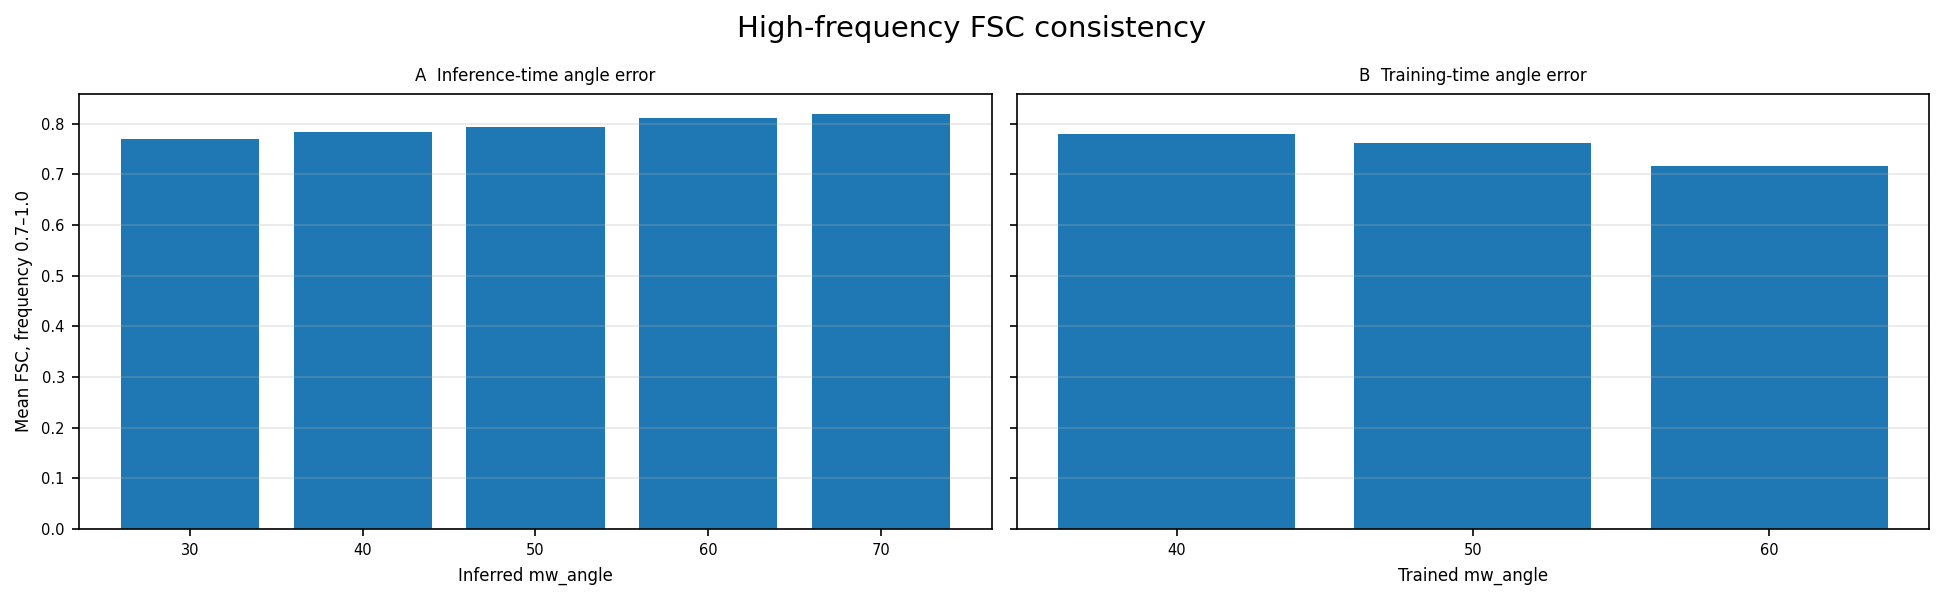

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

# Sub-Exp 1
ax = axes[0]
x1 = subexp01_summary["mw_angle"] if "mw_angle" in subexp01_summary.columns else subexp01_summary["inferred_mw_angle"]
y1 = subexp01_summary["fsc_mean_high_freq"]

ax.bar(x1.astype(str), y1)
ax.set_title("A  Inference-time angle error")
ax.set_xlabel("Inferred mw_angle")
ax.set_ylabel("Mean FSC, frequency 0.7–1.0")
ax.grid(True, axis="y", alpha=0.3)

# Sub-Exp 2
ax = axes[1]
x2 = subexp02_summary["trained_mw_angle"] if "trained_mw_angle" in subexp02_summary.columns else subexp02_summary["mw_angle"]
y2 = subexp02_summary["fsc_mean_high_freq"]

ax.bar(x2.astype(str), y2)
ax.set_title("B  Training-time angle error")
ax.set_xlabel("Trained mw_angle")
ax.grid(True, axis="y", alpha=0.3)

fig.suptitle("High-frequency FSC consistency", fontsize=14)
fig.tight_layout()

os.makedirs("../figures/comparison", exist_ok=True)

png_path = "../figures/comparison/high_frequency_mean_fsc_comparison.png"
pdf_path = "../figures/comparison/high_frequency_mean_fsc_comparison.pdf"

fig.savefig(png_path, dpi=300, bbox_inches="tight")
fig.savefig(pdf_path, bbox_inches="tight")

plt.show()

#### inference-time angle error changes what Fourier region is filled;
#### training-time angle error changes how consistently the model fills the correct region.

Since all even/odd FSC curves remain above the FSC = 0.5 threshold up to the Nyquist frequency, no FSC-0.5 crossing is observed. Therefore, a numerical FSC-0.5 resolution cannot be extracted for these conditions. Instead, we compare the curves directly and use the mean FSC in the high-frequency band 0.7–1.0 as an additional consistency metric.